## 目标与运行方法

下载完整 `.ipynb`，在 VibeIt Studio 文件浏览器中使用 **+ → Import from Files** 导入并打开。按从上到下的顺序运行代码单元；阅读模式中的图表是已保存的真实运行输出。重新运行会从内嵌数据计算结果。

本课适合具备 Python 基础的本科生。先阅读每一步的方法与图注，再修改参数。AI 练习为可选部分，不需要 AI 账号即可完成核心课程。数据写在 notebook metadata 中，不需要另下载数据文件。请保持 notebook 已保存到当前工作文件夹。

学习任务是理解本课的研究问题、执行透明的计算、校验结果，并说明结论的边界。

## 环境与参数

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import re
from collections import Counter
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='hu02-lexical-diversity'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### 读取内嵌快照

下面的加载函数按课程 ID 与 SHA-256 在当前文件夹定位本 notebook，解压后再次校验。文件改名不影响匹配。若找不到数据，确认当前工作目录与文件位置；不要用编造的数据替换它。metadata 随 `.ipynb` 保存及导出，复制代码到单独 `.py` 不会自动复制数据。

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'novels': 'c03763abb21b2380d2934b088f1c22a6d5a4675b17e23534e3f7343dc90084ec'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['novels']


### 方法函数

本课所需函数的完整代码就在下面。它们只使用已列出的预装包与标准库，运行时不会导入任何 cookbook 辅助模块。先检查输入约束和返回值；如果修改算法，后面的校验也需要继续通过。

In [3]:
def strip_ebook_wrapper(raw_text):
    """Return the analysis body while the unmodified source/complete license remain in metadata."""
    text=raw_text.replace('\r\n','\n').replace('\r','\n')
    start=re.search(r'\*\*\* START[^\n]*\*\*\*',text,re.I)
    end=re.search(r'\*\*\* END[^\n]*\*\*\*',text,re.I)
    if not start or not end or end.start()<=start.end():raise ValueError('Ebook start/end markers not found')
    return text[start.end():end.start()]

print("Method ready: strip_ebook_wrapper")


Method ready: strip_ebook_wrapper


In [4]:
def split_novel_chapters(body):
    """Declared two-ebook rule: repeated labels resolve to last heading, excluding their TOCs."""
    headings=list(re.finditer(r'(?im)^\s*chapter\s+([ivxlcdm]+|\d+)[.\]]*\s*$',body))
    if not headings:raise ValueError('No supported chapter headings')
    last={match.group(1).upper():match for match in headings}
    chosen=sorted(last.values(),key=lambda match:match.start());chapters=[]
    for j,match in enumerate(chosen):
        text=body[match.end():chosen[j+1].start() if j+1<len(chosen) else len(body)]
        text=re.sub(r'\[Illustration\b[^\]]*\]',' ',text,flags=re.I|re.S)
        text=text.replace('_','').replace('’',"'").strip()
        if len(text)<300:raise ValueError('Unexpected short chapter after declared TOC rule')
        chapters.append(dict(label=match.group(1).upper(),order=j+1,text=text))
    return chapters

print("Method ready: split_novel_chapters")


Method ready: split_novel_chapters


In [5]:
def tokenize_words(text):
    """Transparent English-letter tokenizer; punctuation/case decisions are part of the method."""
    return re.findall(r"[a-z]+(?:'[a-z]+)?",text.lower().replace('’',"'"))

print("Method ready: tokenize_words")


Method ready: tokenize_words


### 数据与模型边界

快照保留完整未修改来源电子书及原许可。章节分析使用《傲慢与偏见》61 章及《弗兰肯斯坦》24 章；前言和后者书信框架不在本次声明范围。英文字母分词是方法选择，不是语言无关定义。词频、表面模式共现和 SVD 轴不能独立证明作者意图、人物关系或情感。

## 分步分析

### 1. 区分原始 TTR 与文本长度

TTR 为不同归一化词型数除以词数，整部 TTR 强烈受长度影响，不能按两个原始数值排名作者。使用同一声明章节范围。

These source ebooks are available free of charge. Complete unmodified source texts and their licenses are included in this snapshot. Project Gutenberg is acknowledged as the transcription source; its name is not used as a course title or endorsement.
Declared chapter counts: {1342: 61, 84: 24}


,book_id,book,chapter,source_label,characters,tokens
0,1342,Pride and Prejudice,1,I,4490,853
1,1342,Pride and Prejudice,2,II,4293,799
2,1342,Pride and Prejudice,3,III,9560,1704
3,1342,Pride and Prejudice,4,IV,5931,1064
4,1342,Pride and Prejudice,5,V,5246,962
5,1342,Pride and Prejudice,6,VI,13023,2353
6,1342,Pride and Prejudice,7,VII,11263,2000
7,1342,Pride and Prejudice,8,VIII,10993,1936


,book,tokens,types,whole_TTR
0,Pride and Prejudice,122185,6319,0.051717
1,Frankenstein,69610,6703,0.096294


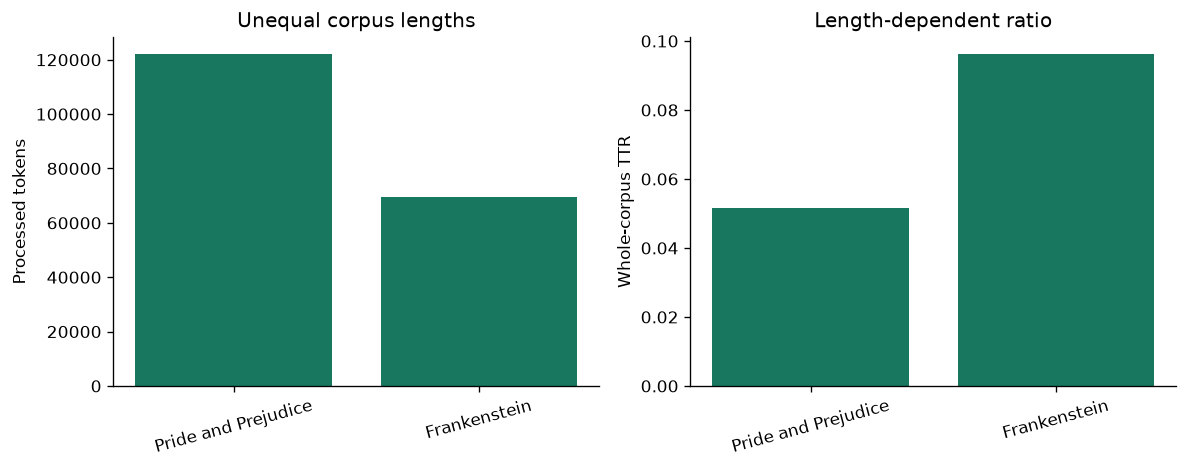

In [6]:
novels=snapshot("novels");corpus={};chapter_rows=[]
for book in novels["books"]:
 chapters=split_novel_chapters(strip_ebook_wrapper(book["raw_text"]))
 tokens=tokenize_words(" ".join(chapter["text"] for chapter in chapters))
 corpus[book["id"]]={"title":book["title"],"author":book["author"],"chapters":chapters,"tokens":tokens}
 for chapter in chapters:chapter_rows.append({"book_id":book["id"],"book":book["title"],"chapter":chapter["order"],"source_label":chapter["label"],"characters":len(chapter["text"]),"tokens":len(tokenize_words(chapter["text"])),"text":chapter["text"]})
chapter_table=pd.DataFrame(chapter_rows)
assert len(corpus[1342]["chapters"])==61 and len(corpus[84]["chapters"])==24
print(novels["source_notice"])
print("Declared chapter counts:",{b:len(corpus[b]["chapters"]) for b in corpus})
display(chapter_table.drop(columns="text").head(8))
summary=pd.DataFrame([{ "book":entry["title"],"tokens":len(entry["tokens"]),"types":len(set(entry["tokens"])),"whole_TTR":len(set(entry["tokens"]))/len(entry["tokens"])} for entry in corpus.values()])
display(summary)
fig,axes=plt.subplots(1,2,figsize=(10,4));axes[0].bar(summary.book,summary.tokens);axes[0].set(ylabel="Processed tokens",title="Unequal corpus lengths")
axes[1].bar(summary.book,summary.whole_TTR);axes[1].set(ylabel="Whole-corpus TTR",title="Length-dependent ratio")
for ax in axes:ax.tick_params(axis="x",rotation=15)
plt.tight_layout();plt.show()


### 2. 匹配连续采样窗口长度

每个长度从各处理语料固定种子抽取 30 个连续窗口，均值/标准差描述该语料窗口变化，不是独立作者实验。相同长度改善可比性。

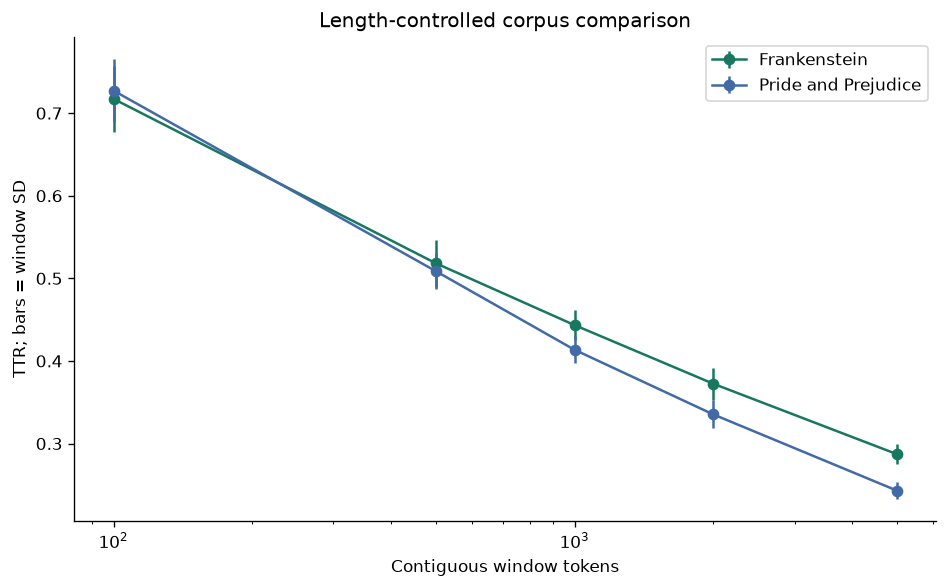

In [7]:
rng=np.random.default_rng(42);lengths=[100,500,1000,2000,5000];records=[]
for book_id,entry in corpus.items():
 tokens=entry["tokens"]
 for length in lengths:
  for repeat in range(30):
   start=int(rng.integers(0,len(tokens)-length+1));window=tokens[start:start+length]
   records.append({"book":entry["title"],"window_tokens":length,"start_token":start,"TTR":len(set(window))/length})
windows=pd.DataFrame(records)
fig,ax=plt.subplots(figsize=(8,5))
for book,part in windows.groupby("book"):
 grouped=part.groupby("window_tokens").TTR.agg(["mean","std"]);ax.errorbar(grouped.index,grouped["mean"],yerr=grouped["std"],fmt="o-",label=book)
ax.set(xscale="log",xlabel="Contiguous window tokens",ylabel="TTR; bars = window SD",title="Length-controlled corpus comparison");ax.legend();plt.tight_layout();plt.show()


### 3. 解读归一化词频—秩曲线

按数量排名并除以各语料总词数，对数坐标展示描述性的长尾形状，不证明普遍语言定律或文学质量。

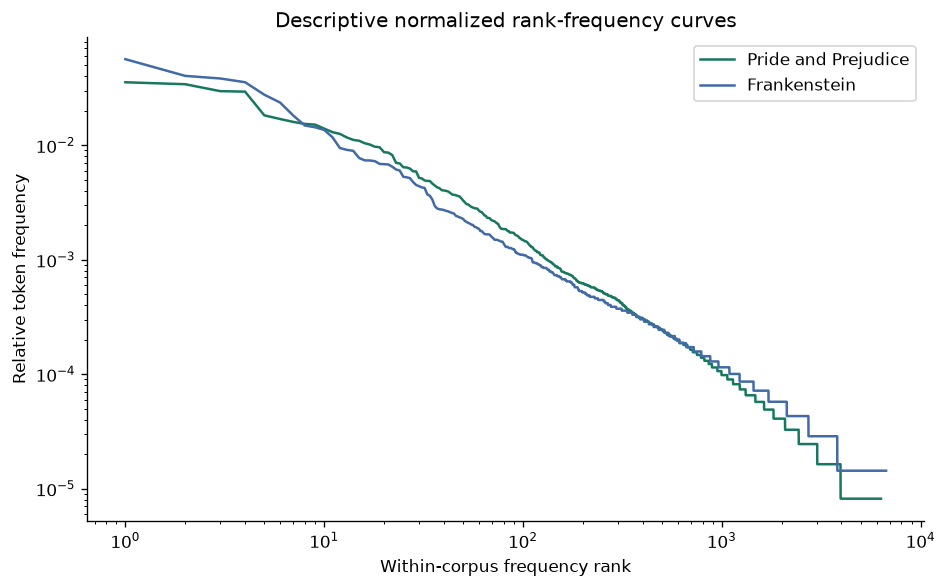

In [8]:
fig,ax=plt.subplots(figsize=(8,5))
for entry in corpus.values():
 frequency=np.array(sorted(Counter(entry["tokens"]).values(),reverse=True));ax.loglog(np.arange(1,len(frequency)+1),frequency/len(entry["tokens"]),label=entry["title"])
ax.set(xlabel="Within-corpus frequency rank",ylabel="Relative token frequency",title="Descriptive normalized rank-frequency curves");ax.legend();plt.tight_layout();plt.show()


### 4. 核对窗口并导出全部抽取

TTR 位于 (0,1]，起点在语料范围，各长度两书重复数量相同。保存所有起点，不能只保留支持偏好解释的窗口。

In [9]:
assert windows.TTR.between(0,1,inclusive="right").all()
assert windows.groupby(["book","window_tokens"]).size().eq(30).all()
OUTPUT_DIR.mkdir(parents=True,exist_ok=True);windows.to_csv(OUTPUT_DIR/"all-matched-windows.csv",index=False)
summary.to_csv(OUTPUT_DIR/"length-dependent-corpus-counts.csv",index=False)
print("Matched-window checks passed; exports:",OUTPUT_DIR)


Matched-window checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/hu02-lexical-diversity


## 自主练习与参考答案

1. 为何不按整书 TTR 排作者？
2. 为何保留匹配窗口及全部起点？

**参考解释。** TTR 依赖长度。等长与起点公开变异，不挑有利段落或编造独立作者样本。

先保留当前 notebook 副本，再修改参数。把新图与原图一起比较，并记录改变了哪些输入、哪些计算和哪些结论。

## 可选的 AI 编程练习

在 VibeIt 的 Coding Agent 中打开当前 notebook，先让助手阅读相关单元。核心课程不依赖 AI 服务；服务可用性与账号设置以应用帮助中心为准。

**提示词 1**

> 仅用 re、Counter、NumPy、Pandas、Matplotlib 加 3000 词等重复窗口及种子。

**提示词 2**

> 同包比较非重叠窗口并说明依赖/范围。

**人工验收。** 比例在 (0,1]，长度/起点合法，不当作新增书。

检查修改后的源代码，再手动运行受影响单元及后续校验。要求助手解释修改的目的、使用的包和数据来源，并用实际输出核对解释。

## 可选联网扩展

默认关闭下面的联网操作。它只显示数据库版本及快照来源，不会替换核心数据。若要重新获取数据，应另存一个实验版本并记录新的 URL、数据库版本、获取日期与 SHA-256；新版结果需要重新执行和核验。

In [10]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://www.gutenberg.org/ebooks/1342',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## 来源、快照与下一步

- [Historical novel 1342](https://www.gutenberg.org/cache/epub/1342/pg1342.txt) — Original novel public domain in USA; complete source ebook and its Project Gutenberg license retained; free distribution and acknowledgment links; retrieved 2026-10-09. SHA-256 `3f6bb9d6f78e0293b56acd4714dd68cb7d6d1d293402031ce9d5a216bcaf9d75`.
  Preserve unmodified UTF-8 source including ebook headers and complete license; preprocessing occurs visibly in the notebook.

- [Historical novel 84](https://www.gutenberg.org/cache/epub/84/pg84.txt) — Original novel public domain in USA; complete source ebook and its Project Gutenberg license retained; free distribution and acknowledgment links; retrieved 2026-10-09. SHA-256 `7810cd483cffcf2cc8a1d8f0d5807931e69d4f48cd14149b8c76f88af82fead3`.
  Preserve unmodified UTF-8 source including ebook headers and complete license; preprocessing occurs visibly in the notebook.


**下一步。** 在保留本课的数据检查、参数记录和结果校验之后，将相同方法用于自己的公开或已获授权数据。记录研究设计与方法限制，不把示例结果当成新实验的验证。完整数据许可与生成说明见 cookbook 网页。